<font size="6.2">Summary</font>  

This work illustrates a multi-step task execution pipeline built with LangChain and LangGraph. The workflow is tailored to tackle complex queries by decomposing them into smaller, manageable steps, executing each sequentially, and re-planning dynamically when necessary. This structured approach enables the agent to effectively handle tasks involving multiple stages, such as retrieving information, interpreting results, and generating a final response.

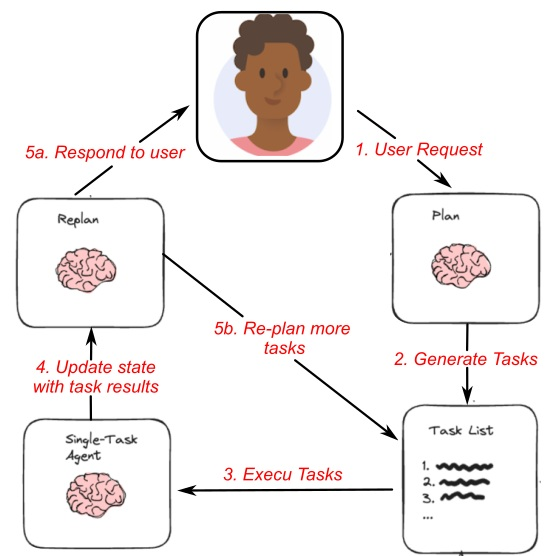

**Steps:**

* **Initialize the LLM:** The process starts by initializing a language model, OpenAI’s GPT-3.5.
* **Tool and Prompt Setup:** Tools like `DuckDuckGoSearchRun` are configured, along with a custom prompt that shapes the agent’s behavior.
* **State and Planning Definition:** A structured state (e.g., `PlanExecute`) is defined to manage the input, plan, past actions, and final output. A planner component creates a step-by-step strategy to reach the task objective.
* **Re-Planning Mechanism:** A replanner dynamically updates the plan based on previous outcomes. If no further steps are needed, it finalizes the response.
* **Graph Construction and Node Definition:** A workflow graph is assembled with nodes representing planning (`plan_node`), execution (`agent_node`), and re-planning (`replan_node`). This graph governs task progression and ensures proper termination.
* **Workflow Execution:** The system is run with an input query, and the agent progresses through each step, ultimately delivering the final result.

Python functions and data files needed to run this notebook are available via this [link](https://github.com/MehdiRezvandehy/Multi-Step-Plan-and-Execute-Agents-with-LangGraph.git).

In [1]:
import warnings
warnings.filterwarnings('ignore')
from langgraph.prebuilt import create_react_agent
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_openai import ChatOpenAI
import datetime
today = datetime.date.today()

# Introduction: What Are Plan & Execute Agents?

**Why Agents Fail**

* **Wrong Tool Selection**: LLMs are non-deterministic and may pick the wrong tool even if it was correct before. Setting temperature to zero and averaging results helps assess reliability.

* **Tool Errors**: Failures often stem from the tool itself (e.g., wrong parameters, scraping issues). Error handling is essential to help agents recover.

* **Infinite Loops**: Agents can get stuck in repetitive steps. Setting a max number of iterations prevents long delays and inefficiency. Agent should be informed for each run how many runs are left to give agent a sense of urgency and out agent on the clock. If not, there would be no real incentive to do things faster or slower. Agent has no idea we want to get things done in timely fashion. 


**Limitations of Chain-of-Thought Prompting**

Chain-of-Thought (CoT) prompting has become a widely recognized and effective method for leveraging large language models (LLMs), particularly in zero- or few-shot settings. It is especially useful for tasks involving multi-step reasoning, where models are guided through examples using the familiar instruction: *"Let us think step by step."*

Despite its strengths, recent research has highlighted three significant limitations in CoT prompting:

* **Arithmetic Errors**: CoT struggles with calculations, showing a 7% failure rate in test cases.
* **Omitted Reasoning Steps**: In tasks involving sequential logic, CoT fails to include all necessary steps 12% of the time.
* **Semantic Misinterpretation**: The most common issue, with a 27% failure rate, involves misunderstanding the core meaning of the input.



**Reasoning and Action (ReAct) Prompting**
Here are the typical **ReAct** steps:

1. **Input**: The user asks a question or gives a task.
2. **Thought**: The LLM reasons about what to do next.
3. **Action**: The LLM chooses a tool to use (e.g., search, calculator).
4. **Observation**: The result from the tool is returned.
5. **Repeat**: The LLM continues reasoning and acting as needed.
6. **Final Answer**: The LLM gives a complete response.
This loop can repeat several times until the task is solved.

The main limitation of ReAct is:
* **Relatively Slow**: it has go through one by one in a sequential manner, we have to wait, if it fails try another approach, it only succeed, it should move on


To address these limitations:

1. **Pre-planned Workflow**: Rather than taking one step at a time, allow the agent to plan the entire workflow in advance. This can improve efficiency and reduce unnecessary steps.

2. **Feedback Mechanisms**: Introduce feedback loops—either real-time or batch—so agents can learn from past actions and adjust future behavior. This goes beyond the standard ReAct approach.


New prompting strategies have been proposed—most notably, **Plan-and-Solve (PS)** and its more detailed variant, Plan-and-Solve with Detailed Instructions (PS+). These approaches aim to improve reasoning quality by separating planning from execution and enforcing clearer, more structured task decomposition. This leads to **smaller and faster LLMs leaving a larger, slower LLM only to plan and return the final answers**.

**Plan & Execute Agents** in LangChain are a powerful pattern designed to handle complex, multi-step tasks by **separating planning from execution**. This approach mimics how humans often solve problems: first we plan what needs to be done, then we execute each step.


They consist of two main components:

1. **Planner**: An agent that breaks down a high-level task into smaller subtasks or steps.
2. **Executor**: A separate agent that takes each subtask and performs it, one at a time.

This separation allows the system to tackle longer or more structured tasks more reliably than typical reactive agents.


✅ Why Use Them?

* They reduce hallucination by providing more structure.
* They work better for long, complex workflows (e.g., research, summarization, multi-stage reasoning).
* You can plug in different LLMs or tools for planning vs executing.

---

🧩 Example Use Cases

1. **Multi-Document Research Assistant**

* **User query**: “Summarize the viewpoints of three different articles on climate change policy.”
* **Planner**: Breaks it into steps:

  * Find three articles
  * Extract main viewpoint from each
  * Compare and summarize differences
* **Executor**: Uses tools like a search engine, text extraction, and summarization for each subtask.

---

2. **Code Generation and Testing**

* **User query**: “Build a Python script that scrapes product prices and saves them to CSV.”
* **Planner**:

  * Step 1: Find a site to scrape
  * Step 2: Write scraper code
  * Step 3: Save results to CSV
  * Step 4: Test and handle errors
* **Executor**: Generates and tests each part of the code one step at a time.

---

3. **Travel Planning Assistant**

* **User query**: “Plan a one-week trip to Japan focusing on cultural experiences.”
* **Planner**: Breaks it into daily plans with key activities and locations.
* **Executor**: Looks up cultural events, local sites, and creates itineraries for each day.


**Advantages of Plan-and-Execute Agents over ReAct Agents**

Plan-and-execute agents offer several key benefits compared to traditional ReAct agents:

⏱ **Faster Execution**: By decoupling planning from execution, sub-tasks can proceed without repeatedly consulting the main LLM. This enables multi-step workflows to run more efficiently, especially when using lightweight models or no LLM calls for execution steps.

💰 **Cost Efficiency**: These agents reduce inference costs by limiting the use of large, general-purpose LLMs. Instead, sub-tasks can be handled by smaller, domain-specific models, reserving the larger model only for planning and final response generation.

🎯 **Improved Task Performance**: Forcing the agent to plan all steps upfront encourages better reasoning and clarity. This structured decomposition supports more targeted execution and leverages the effectiveness of step-by-step thinking—leading to higher task completion rates and response quality.


In [ ]:
import os

os.environ["OPENAI_API_KEY"] = 'sk-proj-....................................'
llm_model = "gpt-3.5-turbo"

# Basic ReAct Agent using `create_react_agent`

In [3]:
# Define DuckDuckGoSearchRun for internet search
search_tool = [DuckDuckGoSearchRun()]

# Call create_react_agent with the model argument positionally
agent_executor = create_react_agent(
    f"openai:{llm_model}",
#    "openai:gpt-4o-mini",
    tools=search_tool,
    prompt="You are a helpful assistant."
)

# Invoke
response = agent_executor.invoke({"messages":[{"role":"user","content": "Who won 2024–25 Persian Gulf Pro League?"}]})
print(response)

D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


{'messages': [HumanMessage(content='Who won 2024–25 Persian Gulf Pro League?', additional_kwargs={}, response_metadata={}, id='98ade2da-df24-4eb8-9a1d-d8d11ae178a8'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_7n4DB99uLhRb7NpGjREUjzIP', 'function': {'arguments': '{"query":"2024–25 Persian Gulf Pro League winner"}', 'name': 'duckduckgo_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 94, 'total_tokens': 119, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--09bd4f23-fe3d-499d-b78c-23906a9a28d2-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': '2024–25 Persian Gulf Pro League winner'}, 'id': 'call_

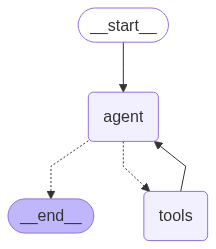

In [4]:
agent_executor

In [5]:
response['messages'][-1].content 

"I couldn't find the specific information on the winner of the 2024–25 Persian Gulf Pro League. Would you like me to try again or assist you with something else?"

LangGraph's `create_react_agent` answered the question correctly. Let's built a ReAct from scratch:

In [6]:
# without using create_react_agent
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableMap
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI
from langchain_community.tools import DuckDuckGoSearchRun
from langchain import hub

# --- Step 1: Initialize the tool ---
search_ddg_tool = DuckDuckGoSearchRun()
tools = [search_ddg_tool]
tool_names = [tool.name for tool in tools]

# --- Step 2: Pull the prompt ---
prompt = hub.pull("hwchase17/react")
print("📥 Pulled Prompt Template:")
print(prompt.template)

# --- Step 3: Initialize the LLM ---
llm = ChatOpenAI(model=llm_model)

# --- Step 4: Manually create a Runnable chain ---
def format_tools_str(tools):
    return "\n".join([f"{tool.name}: {tool.description}" for tool in tools])

def format_tool_names(tools):
    return ", ".join([tool.name for tool in tools])

chain = (
    RunnableMap({
        "input": lambda x: x["input"],
        "tools": lambda _: format_tools_str(tools),
        "tool_names": lambda _: format_tool_names(tools),
        "agent_scratchpad": lambda _: "",  # empty at start
    })
    | prompt
    | (lambda prompt_result: (
        print("\n📝 Prompt sent to LLM:\n", prompt_result) or prompt_result
    ))
    | llm
    | (lambda llm_result: (
        print("\n🤖 Raw LLM response:\n", llm_result) or llm_result
    ))
    | StrOutputParser()
    | (lambda parsed: (
        print("\n✅ Final Parsed Output:\n", parsed) or parsed
    ))
)

# --- Step 5: Invoke the chain ---
question = "Who won 2024–25 Persian Gulf Pro League?"
print(f"\n🔍 Asking: {question}")
response = chain.invoke({"input": question})


D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\langsmith\client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


📥 Pulled Prompt Template:
Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: {input}
Thought:{agent_scratchpad}

🔍 Asking: Who won 2024–25 Persian Gulf Pro League?

📝 Prompt sent to LLM:
 text='Answer the following questions as best you can. You have access to the following tools:\n\nduckduckgo_search: A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about current events. Input should be a search query.\n\nUse the following format:\n\nQuestion: the input question you mus

The answer is wrong so LangGraph's `create_react_agent` works better than making a ReAct from scratch.

# Develop **Planner**

In [7]:
from typing import List
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

# Define the expected structure of a plan using Pydantic
class Plan(BaseModel):
    """Structured plan containing ordered steps to accomplish a goal."""
    # make streps attributes which is a list of steps (strings) to answer the question
    steps: List[str] = Field(
        description="A list of steps to follow in sequential order to achieve the objective."
    )

# Create the system prompt to guide the planner: it is our own prompt not from pre-built prompts
planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """Given an objective, break it down into a step-by-step plan. \
Each step should be actionable and self-contained, leading to the final answer. \
Avoid unnecessary steps. Ensure every step includes all required information to proceed."""
        ),
        ("placeholder", "{messages}"), # back and forth conversation
    ]
)

# Create the planner by combining the prompt and the LLM with structured output
planner = planner_prompt | ChatOpenAI(model=llm_model, temperature=0).with_structured_output(Plan)

In [8]:
# Ask the planner to generate a step-by-step plan for the given question
plan = planner.invoke(
    {
        "messages": [("user", "what are best promotions for TD bank for mortage and loan?")]
    }
)

# Display the generated plan
plan

Plan(steps=['Research current promotions offered by TD Bank for mortgages and loans.', 'Compare the promotions to determine which ones offer the best value in terms of interest rates, fees, and benefits.', 'Consider the specific needs and financial situation to determine which promotion is most suitable.', 'Contact TD Bank for more information and to discuss the selected promotion in detail.', 'Apply for the chosen promotion following the application process provided by TD Bank.'])

In [9]:
from typing import Union
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI



# Define a model to represent a direct user response
class Response(BaseModel):
    """Response to user."""
    response: str

# Define the possible agent action: either respond or revise the plan (Union)
class Act(BaseModel):
    """Action to perform: either a final response or a revised plan."""
    action: Union[Response, Plan] = Field(
        description="If the task is complete, use Response to reply to the user. "
                    "If more work is needed, return a Plan with remaining steps."
    )

## Replanner Agent

A Replanner Agent improves reliability by creating an initial plan and then dynamically adjusting it based on intermediate results. This allows it to handle unexpected outcomes more effectively than static agents, while also reducing the number of expensive LLM calls during execution. It's ideal for complex, multi-step tasks in unpredictable environments.

**Why Use a Replanner Agent?**

1. **Robustness to Uncertainty**:
Real-world environments are often unpredictable. The ability to replan allows the agent to recover gracefully from unexpected outcomes or incorrect assumptions.

2. **More Efficient than ReAct**:
Unlike ReAct agents that consult the LLM after every step (which is slow and expensive), a replanner agent executes plans more independently and only re-engages the LLM when needed for adjustment.

3. **Improved Task Completion**:
By combining the foresight of planning with the flexibility of real-time adaptation, replanner agents tend to perform better on complex, multi-step tasks—especially when new data or edge cases emerge mid-task.

4. **Cost Savings**:
Fewer LLM calls during execution means reduced compute cost, while still maintaining high reliability through selective re-planning

This step below outlines the re-planning logic, where the replanner adjusts the plan based on the outcomes of earlier steps. If no additional steps are required, it provides the final response.

In [10]:
# Prompt to re-evaluate and update the original plan based on progress
replanner_prompt = ChatPromptTemplate.from_template(
    """For the given objective, come up with a simple step-by-step plan. \
Each step should be concrete and necessary to reach the final answer. Do not include unnecessary steps. \
Ensure each step includes all the information needed to complete it.

Objective:
{input}

Original plan:
{plan}

Steps already completed:
{past_steps}

Update your plan accordingly. If no more steps are needed and you can respond to the user, do so. \
Otherwise, return only the remaining necessary steps in a Plan."""
)

# Combine the prompt with the model and output schema
replanner = replanner_prompt | ChatOpenAI(model=llm_model, temperature=0).with_structured_output(Act)


In [11]:
act = replanner.invoke(
    {
        "input": f"what is mortgage  rate for TD bank today ({today})?",
        "plan": plan,
        "past_steps": ['Research current promotions offered by TD Bank for mortgages and loans.'],
        
    }
)

In [12]:
# New steps
new_plan = act.action
new_plan

Plan(steps=['Compare the interest rates offered by TD Bank for mortgages on the specific date (2025-07-22).', 'Evaluate the terms and conditions associated with the mortgage rates to understand any additional fees or requirements.', 'Contact TD Bank to inquire about the current mortgage rates for the selected date (2025-07-22).', 'Review the information provided by TD Bank and consider the best mortgage rate option based on the research and discussions.', 'Proceed with the application process for the chosen mortgage rate option at TD Bank.'])

In [13]:
type(new_plan)

__main__.Plan

In [14]:
new_plan.steps

['Compare the interest rates offered by TD Bank for mortgages on the specific date (2025-07-22).',
 'Evaluate the terms and conditions associated with the mortgage rates to understand any additional fees or requirements.',
 'Contact TD Bank to inquire about the current mortgage rates for the selected date (2025-07-22).',
 'Review the information provided by TD Bank and consider the best mortgage rate option based on the research and discussions.',
 'Proceed with the application process for the chosen mortgage rate option at TD Bank.']

# Building the Graph

In [15]:
import operator
from typing import Annotated, List, Tuple
from typing_extensions import TypedDict

# Define the state object passed between nodes in the LangGraph.
# This acts like short-term memory for the agent.
class PlanExecute(TypedDict):
    input: str                          # Original user query
    plan: List[str]                     # List of planned steps to execute
    past_steps: Annotated[List[Tuple], operator.add]  # Log of executed steps + results
    response: str                       # Final answer, if available

In [16]:
from typing import Literal
from langgraph.graph import END

def execute_step(state: PlanExecute):
    """
    Executes the next step in the plan using an external agent.
    """

    plan = state["plan"]  # Full plan
    task = plan[0]        # Next task to execute

    # Format plan for context
    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))
    task_formatted = f"""For the following plan:
{plan_str}

You are tasked with executing step 1, {task}."""

    # Debug print for clarity
    print('-----------------------')
    print('Formatted Task at Execute', task_formatted)
    print('-----------------------')

    # Invoke the executor agent
    agent_response = agent_executor.invoke({
        "messages": [("user", task_formatted)]
    })

    # Return the result of the step execution to be stored in `past_steps`
    return {
        "past_steps": [(task, agent_response["messages"][-1].content)],
    }


In [17]:
def plan_step(state: PlanExecute):
    """
    Uses the planner to create an initial list of steps (plan) from the input query.
    """
    plan = planner.invoke({"messages": [("user", state["input"])]})
    return {"plan": plan.steps}

#---------------------------------------------------

def replan_step(state: PlanExecute):
    """
    Re-evaluates the plan based on current state (replanning).
    If a final answer is produced, return it. Otherwise, return a new or updated plan.
    """
    output = replanner.invoke(state)

    if isinstance(output.action, Response):
        print('A response was given!')
        return {"response": output.action.response}
    else:
        return {"plan": output.action.steps}

#---------------------------------------------------

def should_end(state: PlanExecute):
    """
    Decides whether the graph should terminate.
    If a final response is present, end the execution.
    Otherwise, continue executing the plan.
    """
    if "response" in state and state["response"]:
        return END
    else:
        return "executor"


In [18]:
from langgraph.graph import StateGraph, START

# Initialize a stateful graph with the PlanExecute type as the shared state structure
workflow = StateGraph(PlanExecute)

# Add the node that creates a multi-step plan based on user input
workflow.add_node("plan_node", plan_step)

# Add the node that executes a single step from the plan
workflow.add_node("executor", execute_step)

# Add the node that checks whether to replan or respond
workflow.add_node("replan_node", replan_step)

# Define the start of the workflow — begin by planning
workflow.add_edge(START, "plan_node")

# After planning, move on to executing the first step
workflow.add_edge("plan_node", "executor")

# After execution, transition to the replanner to evaluate the result
workflow.add_edge("executor", "replan_node")

# Add conditional branching from the replan node:
# If a final response is available, end the workflow.
# Otherwise, go back and execute the next step.
workflow.add_conditional_edges(
    "replan_node",
    should_end,          # Function that decides whether to continue or end
    ["executor", END],   # Options: continue executing or finish
)


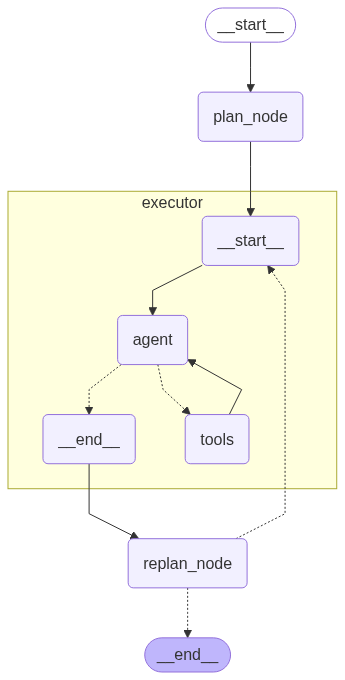

In [19]:
# Compile the defined workflow into an executable application
app = workflow.compile()

# Visualize the graph structure using Mermaid and display it in a Jupyter notebook
from IPython.display import Image, display

# Generate and display a PNG image of the graph with internal node details (xray=True)
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

## Using our Plan & Execute Agent

In [20]:
inputs = {"input": f"what is mortgage  rate for TD bank today ({today})?"}

# Stream the execution of the workflow step-by-step
for event in app.stream(inputs):  # 'inputs' should be a valid PlanExecute input dictionary
    for node_name, output in event.items():
        # Print the name of the current node and its output
        print(f'Node: {node_name}. Output: {output}\n\n')


Node: plan_node. Output: {'plan': ['Visit the TD Bank website.', 'Navigate to the mortgage rates section.', "Check the current mortgage rates for today's date (2025-07-22)."]}


-----------------------
Formatted Task at Execute For the following plan:
1. Visit the TD Bank website.
2. Navigate to the mortgage rates section.
3. Check the current mortgage rates for today's date (2025-07-22).

You are tasked with executing step 1, Visit the TD Bank website..
-----------------------


D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


Node: executor. Output: {'past_steps': [('Visit the TD Bank website.', 'I found the TD Bank website where you can access their services, including mortgage rates. You can visit the TD Bank website [here](https://www.td.com/).')]}


Node: replan_node. Output: {'plan': ['Navigate to the mortgage rates section.', "Check the current mortgage rates for today's date (2025-07-22)."]}


-----------------------
Formatted Task at Execute For the following plan:
1. Navigate to the mortgage rates section.
2. Check the current mortgage rates for today's date (2025-07-22).

You are tasked with executing step 1, Navigate to the mortgage rates section..
-----------------------


D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


Node: executor. Output: {'past_steps': [('Navigate to the mortgage rates section.', "I have found information on current mortgage rates. Would you like me to proceed with checking the rates for today's date (2025-07-22)?")]}


Node: replan_node. Output: {'plan': ['Check the mortgage rates for TD Bank on the TD Bank website for the specific date: 2025-07-22.']}


-----------------------
Formatted Task at Execute For the following plan:
1. Check the mortgage rates for TD Bank on the TD Bank website for the specific date: 2025-07-22.

You are tasked with executing step 1, Check the mortgage rates for TD Bank on the TD Bank website for the specific date: 2025-07-22..
-----------------------


...

Node: executor. Output: {'past_steps': [('Check the mortgage rates for TD Bank on the TD Bank website for the specific date: 2025-07-22.', "I found information related to TD Bank mortgage rates on July 22, 2025. It seems that the search results provide general information about mortgage interest rates and forecasts for various dates, including July 16, 2025. For specific details on TD Bank's mortgage rates on July 22, 2025, you may need to visit the TD Bank website directly or contact them for the most up-to-date information.")]}


Node: replan_node. Output: {'plan': ['Check the mortgage rates for TD Bank on the TD Bank website for the specific date: 2025-07-22.']}


-----------------------
Formatted Task at Execute For the following plan:
1. Check the mortgage rates for TD Bank on the TD Bank website for the specific date: 2025-07-22.

You are tasked with executing step 1, Check the mortgage rates for TD Bank on the TD Bank website for the specific date: 2025-07-22..
-----------------

D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


Node: executor. Output: {'past_steps': [('Check the mortgage rates for TD Bank on the TD Bank website for the specific date: 2025-07-22.', "I found information on TD Bank mortgage rates for July 15, 2025, where the rate is held at 2.75%. Unfortunately, I couldn't retrieve specific rates for July 22, 2025. If you need more detailed information, you may consider checking directly on the TD Bank website or contacting them for accurate rates on that specific date.")]}


Node: replan_node. Output: {'plan': ['Visit the TD Bank website or contact TD Bank directly to inquire about the mortgage rates for July 22, 2025.']}


-----------------------
Formatted Task at Execute For the following plan:
1. Visit the TD Bank website or contact TD Bank directly to inquire about the mortgage rates for July 22, 2025.

You are tasked with executing step 1, Visit the TD Bank website or contact TD Bank directly to inquire about the mortgage rates for July 22, 2025..
-----------------------


D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


Node: executor. Output: {'past_steps': [('Visit the TD Bank website or contact TD Bank directly to inquire about the mortgage rates for July 22, 2025.', 'I found information on July 22, 2025, regarding mortgage rates. According to the search results, on July 22, 2025, mortgage rates have risen, and there may have been updates or announcements from the Federal Reserve. For specific mortgage rates from TD Bank on this date, I recommend visiting the TD Bank website directly or contacting TD Bank for the most accurate and up-to-date information.')]}


A response was given!
Node: replan_node. Output: {'response': 'To find the mortgage rate for TD Bank on July 22, 2025, you should directly visit the TD Bank website or contact TD Bank for the most accurate and up-to-date information.'}




In [21]:
# Stream the graph execution, focusing on state changes only (not individual node outputs)
for event in app.stream(inputs, stream_mode=['values']):  # stream_mode=['values'] yields (step_id, state)
    # event is a tuple: (step_id, updated_state)
    step_id, state = event

    # Print the number of past steps and their current content
    print(len(state.get('past_steps')), state.get('past_steps'))


0 []
0 []
-----------------------
Formatted Task at Execute For the following plan:
1. Visit the TD Bank website.
2. Navigate to the mortgage rates section.
3. Check the current mortgage rates for today's date (2025-07-22).

You are tasked with executing step 1, Visit the TD Bank website..
-----------------------


D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


1 [('Visit the TD Bank website.', 'I have found information about TD Bank on their official website. You can explore their banking services, credit cards, loans, home lending, and other financial products by visiting their website.')]
1 [('Visit the TD Bank website.', 'I have found information about TD Bank on their official website. You can explore their banking services, credit cards, loans, home lending, and other financial products by visiting their website.')]
-----------------------
Formatted Task at Execute For the following plan:
1. Navigate to the mortgage rates section.
2. Check the current mortgage rates for today's date (2025-07-22).

You are tasked with executing step 1, Navigate to the mortgage rates section..
-----------------------


D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


2 [('Visit the TD Bank website.', 'I have found information about TD Bank on their official website. You can explore their banking services, credit cards, loans, home lending, and other financial products by visiting their website.'), ('Navigate to the mortgage rates section.', "I have searched for mortgage rates, and I found information on current mortgage rates from various sources. Is there a specific source you would like me to explore further for today's date (2025-07-22)?")]
2 [('Visit the TD Bank website.', 'I have found information about TD Bank on their official website. You can explore their banking services, credit cards, loans, home lending, and other financial products by visiting their website.'), ('Navigate to the mortgage rates section.', "I have searched for mortgage rates, and I found information on current mortgage rates from various sources. Is there a specific source you would like me to explore further for today's date (2025-07-22)?")]
-----------------------
Form

D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


3 [('Visit the TD Bank website.', 'I have found information about TD Bank on their official website. You can explore their banking services, credit cards, loans, home lending, and other financial products by visiting their website.'), ('Navigate to the mortgage rates section.', "I have searched for mortgage rates, and I found information on current mortgage rates from various sources. Is there a specific source you would like me to explore further for today's date (2025-07-22)?"), ("Check the mortgage rates section on the TD Bank website for today's date (2025-07-22).", 'I found information on TD Bank mortgage rates for July 22, 2025. The mortgage rate forecast for July 2025 is starting at 3.89% with a maximum of 4.11% and a minimum of 3.82%. The current rate is 3.95%. Additionally, the 5-year fixed rate at the end of the month is expected to be 3.99%.\n\nIf you need more detailed information or have any specific questions, feel free to ask!')]
A response was given!
3 [('Visit the TD B

In [22]:
last_state = event[1]
last_state

{'input': 'what is mortgage  rate for TD bank today (2025-07-22)?',
 'plan': ["Check the mortgage rates section on the TD Bank website for today's date (2025-07-22)."],
 'past_steps': [('Visit the TD Bank website.',
   'I have found information about TD Bank on their official website. You can explore their banking services, credit cards, loans, home lending, and other financial products by visiting their website.'),
  ('Navigate to the mortgage rates section.',
   "I have searched for mortgage rates, and I found information on current mortgage rates from various sources. Is there a specific source you would like me to explore further for today's date (2025-07-22)?"),
  ("Check the mortgage rates section on the TD Bank website for today's date (2025-07-22).",
   'I found information on TD Bank mortgage rates for July 22, 2025. The mortgage rate forecast for July 2025 is starting at 3.89% with a maximum of 4.11% and a minimum of 3.82%. The current rate is 3.95%. Additionally, the 5-year 

In [23]:
event

('values',
 {'input': 'what is mortgage  rate for TD bank today (2025-07-22)?',
  'plan': ["Check the mortgage rates section on the TD Bank website for today's date (2025-07-22)."],
  'past_steps': [('Visit the TD Bank website.',
    'I have found information about TD Bank on their official website. You can explore their banking services, credit cards, loans, home lending, and other financial products by visiting their website.'),
   ('Navigate to the mortgage rates section.',
    "I have searched for mortgage rates, and I found information on current mortgage rates from various sources. Is there a specific source you would like me to explore further for today's date (2025-07-22)?"),
   ("Check the mortgage rates section on the TD Bank website for today's date (2025-07-22).",
    'I found information on TD Bank mortgage rates for July 22, 2025. The mortgage rate forecast for July 2025 is starting at 3.89% with a maximum of 4.11% and a minimum of 3.82%. The current rate is 3.95%. Additi